## Imports

In [16]:
import sys
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.loaders.load_kaggle_data import load_data
from src.splits.splitting import create_stratified_kfold
from src.preprocessing.preprocessing import split_features_target
from src.preprocessing.preprocessing import get_feature_types
from src.preprocessing.preprocessing import (
    create_one_hot_preprocessor,
)
from src.models.xgboost import build_xgboost
from src.submission.submission import create_submission

## Load data

In [2]:
train, test, sample_submission = load_data()

TARGET = "Will_Buy_EV"
ID_COLUMN = "id"

X, y = split_features_target(
    train,
    target=TARGET,
)

X = X.drop(columns=[ID_COLUMN])

X_test = test.drop(columns=[ID_COLUMN])

print("X columns:")
print(X.columns.tolist())

print("\nX_test columns:")
print(X_test.columns.tolist())

print(f"\nNumber of features: {X.shape[1]}")
print(f"X shape: {X.shape}")
print(f"X_test shape: {X_test.shape}")

print("\nSame features in X and X_test:", X.columns.equals(X_test.columns))

X columns:
['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level', 'Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level']

X_test columns:
['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level', 'Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level']

Number of features: 13
X shape: (668665, 13)
X_test shape: (286571, 13)

Same features in X and X_test: True


## Cross-validation strategy

In [3]:
cv = create_stratified_kfold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

print(cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


## Identify numerical & categorical features

In [4]:
numeric_features, categorical_features = get_feature_types(X)


preprocessor = create_one_hot_preprocessor(
    categorical_features=categorical_features,
)

## Build the model

In [5]:
classifier = build_xgboost()

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", classifier),
    ]
)

## Hyperparameter space

In [6]:
param_distributions = {
    "classifier__n_estimators": [200, 400, 600, 800, 1000],
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "classifier__max_depth": [3, 4, 5, 6, 8, 10],
    "classifier__subsample": [0.7, 0.8, 0.9, 1.0],
    "classifier__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
}

In [7]:
search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=2,
    return_train_score=True,
)

search.fit(X, y)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__colsample_bytree': [0.7, 0.8, ...], 'classifier__learning_rate': [0.01, 0.03, ...], 'classifier__max_depth': [3, 4, ...], 'classifier__n_estimators': [200, 400, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be com

In [8]:
results = pd.DataFrame(search.cv_results_)

results = results[
    [
        "rank_test_score",
        "params",
        "mean_test_score",
        "std_test_score",
        "split0_test_score",
        "split1_test_score",
        "split2_test_score",
        "split3_test_score",
        "split4_test_score",
    ]
].sort_values("rank_test_score")

results

,rank_test_score,params,mean_test_score,std_test_score,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score
10,1,"{'classifier__subsample': 1.0, 'classifier__n_...",0.942077,0.000785,0.940781,0.941856,0.943117,0.942595,0.942039
8,2,"{'classifier__subsample': 0.9, 'classifier__n_...",0.941872,0.000746,0.940647,0.941630,0.942839,0.942409,0.941838
12,3,"{'classifier__subsample': 0.7, 'classifier__n_...",0.941715,0.000775,0.940484,0.941418,0.942770,0.942246,0.941659
16,4,"{'classifier__subsample': 0.7, 'classifier__n_...",0.941644,0.000805,0.940308,0.941386,0.942657,0.942247,0.941623
17,5,"{'classifier__subsample': 1.0, 'classifier__n_...",0.941584,0.000765,0.940283,0.941356,0.942521,0.942135,0.941624
4,6,"{'classifier__subsample': 0.8, 'classifier__n_...",0.941523,0.000748,0.940312,0.941312,0.942537,0.942022,0.941432
5,7,"{'classifier__subsample': 0.9, 'classifier__n_...",0.941232,0.000730,0.940019,0.940952,0.942166,0.941723,0.941298
13,8,"{'classifier__subsample': 1.0, 'classifier__n_...",0.941146,0.000730,0.939907,0.940922,0.942082,0.941589,0.941232
14,9,"{'classifier__subsample': 0.7, 'classifier__n_...",0.941138,0.000738,0.939955,0.940810,0.942145,0.941586,0.941193
6,10,"{'classifier__subsample': 0.9, 'classifier__n_...",0.941020,0.000796,0.939680,0.940833,0.941990,0.941644,0.940951


In [9]:
best_params = search.best_params_

print("Best ROC-AUC:", search.best_score_)
print("Best parameters:")
print(best_params)

Best ROC-AUC: 0.9420774768498852
Best parameters:
{'classifier__subsample': 1.0, 'classifier__n_estimators': 1000, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.1, 'classifier__colsample_bytree': 0.9}


In [11]:
best_xgb = build_xgboost(
    **{
        key.replace("classifier__", ""): value
        for key, value in best_params.items()
    }
)

final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", best_xgb),
    ]
)

final_model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['Age','Annual_Income_USD','Daily_Commute_km',...,'Home_Charging_Possible', 'Subsidy_Available','Range_Anxiety_Level']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).B

In [13]:
submission = create_submission(
    model=final_model,
    test=test,
    sample_submission=sample_submission,
    target=TARGET,
    output_filename="submission_xgb_random_search.csv",
)

display(submission.head())

Saved: C:\Users\Darío\Desktop\KAGGLE\kaggle_ev_adoption\data\outputs\submission_xgb_random_search.csv


,id,Will_Buy_EV
0,668665,0.010531
1,668666,0.014977
2,668667,0.004931
3,668668,0.002550
4,668669,0.023615


In [14]:
preprocessor = final_model.named_steps["preprocessor"]
classifier = final_model.named_steps["classifier"]

feature_names = preprocessor.get_feature_names_out()

importance = classifier.feature_importances_

feature_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importance,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance.head(20))

,feature,importance
0,categorical__Subsidy_Available_No,0.342225
1,categorical__Subsidy_Available_Yes,0.310317
2,remainder__Environmental_Concern_Level,0.265198
3,categorical__Range_Anxiety_Level_Low,0.052075
4,remainder__Annual_Income_USD,0.009691
5,categorical__Home_Charging_Possible_Yes,0.004021
6,categorical__Home_Charging_Possible_No,0.003774
7,categorical__Range_Anxiety_Level_High,0.001632
8,remainder__Daily_Commute_km,0.001289
9,remainder__Age,0.001044


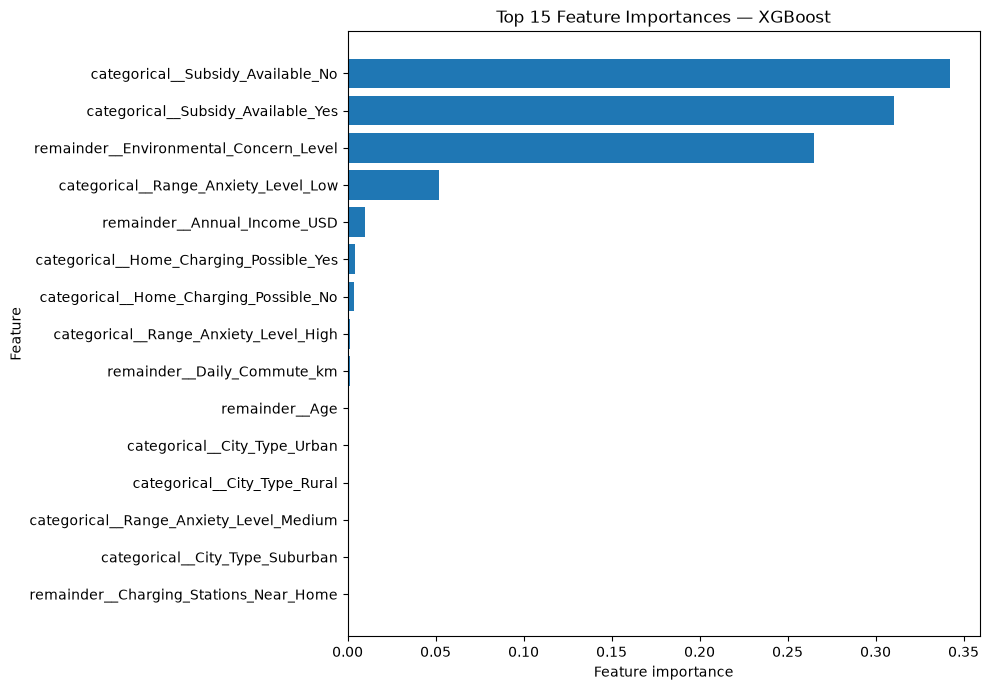

In [17]:
top_n = 15

top_features = feature_importance.head(top_n).sort_values(
    "importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"],
)

plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances — XGBoost")

plt.tight_layout()
plt.show()